# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPool2D , Flatten , Dense , Dropout , BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix , classification_report
import seaborn as sns

# Load the Dataset

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


# Sample Image

Text(0.5, 1.0, 'Label: 5')

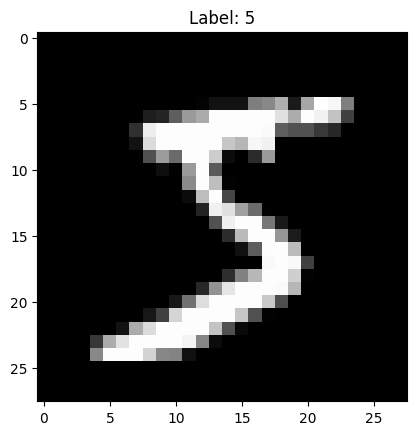

In [3]:
plt.imshow(X_train[0],cmap='gray')
plt.title(f"Label: {y_train[0]}")

# Preprocessing of the data

In [4]:
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# Build the CNN

In [5]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64,(3,3),padding="same",activation="relu"))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2)))

model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(10,activation="softmax"))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

# Compile and Train

In [6]:
early_stop=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
  X_train,y_train,
  epochs=10,
  validation_split=0.1,
  callbacks=[early_stop]
)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 97s 56ms/step - accuracy: 0.9491 - loss: 0.1733 - val_accuracy: 0.9808 - val_loss: 0.0620
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9775 - loss: 0.0785 - val_accuracy: 0.9773 - val_loss: 0.0858
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 141s 53ms/step - accuracy: 0.9829 - loss: 0.0593 - val_accuracy: 0.9863 - val_loss: 0.0565
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9867 - loss: 0.0453 - val_accuracy: 0.9900 - val_loss: 0.0433
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9873 - loss: 0.0414 - val_accuracy: 0.9865 - val_loss: 0.0608
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 90s 53ms/step - accuracy: 0.9892 - loss: 0.0360 - val_accuracy: 0.9900 - val_loss: 0.0580
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 92s 54ms/step - accuracy: 0.9906 - loss: 0.0306 - val_accuracy: 0.9902 - val_loss: 0.0611


# Plot Result

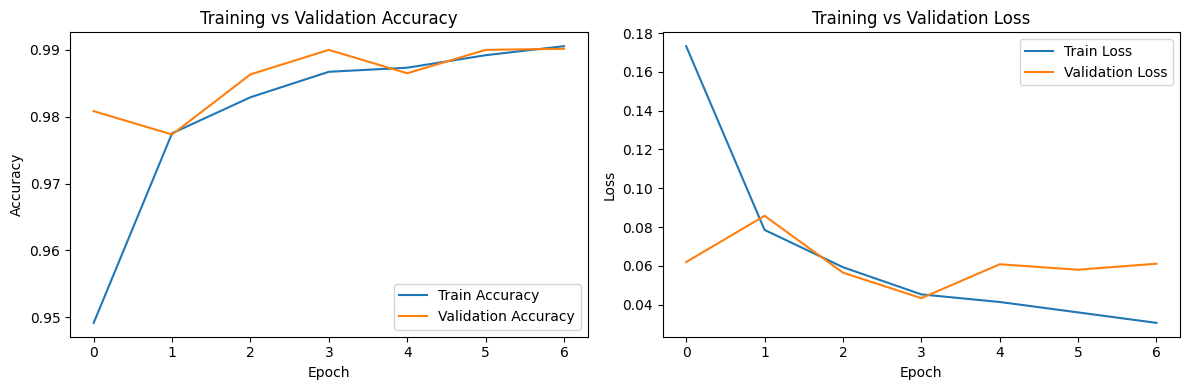

In [7]:
# Accuracy plot
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on the test data

In [8]:
test_loss,test_acc = model.evaluate(X_test,y_test)
print(f"Test Accuracy: {test_acc:4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9908 - loss: 0.0355
Test Accuracy: 0.990800


# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


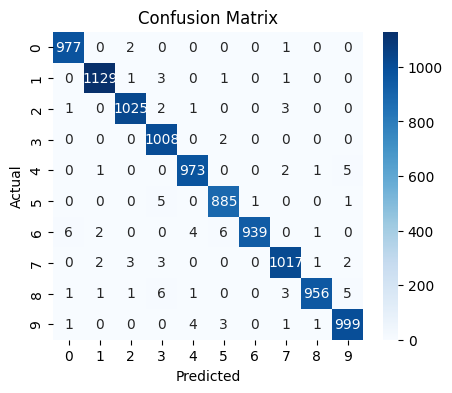

In [9]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Test on one specific image

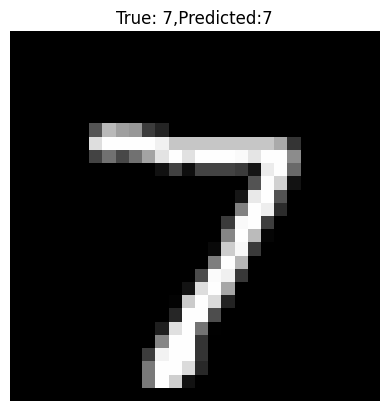

In [10]:
index = 0
plt.imshow(X_test[index].reshape(28,28),cmap="grey")
plt.title(f"True: {y_test[index]},Predicted:{predicted_classes[index]}")
plt.axis("off")
plt.show()